# CDGS production

These examples are related to the production of a Common Decay Gamma Source (CDGS) file starting from a cloud point (often coming from a flunet calculation)

## Preliminary considerations

Before diving into the example it is useful to understand a few concept related to the production of a CDGS. The input is often a cloud point (cell centers) coming from a CFD simulation of the number of specific radio-isotopes per m3. The first step is to create a structured mesh from the cell centers of an unstructured one. F4Enix will do this automatically with the user able to choose if the mesh steps should be the minimum, average or maximum distance between cell centers. 

In this case, showing is easier than explaining:

In [2]:
# from f4enix.output.cdgs import _get_regular_mesh
# import pyvista as pv
# from f4enix.output.cdgs import BIN_SIZING
# import numpy as np
# from scipy.spatial import Delaunay


# # Generate points
# n = 20
# r = np.sqrt(np.random.rand(n))
# theta = 2*np.pi*np.random.rand(n)
# points = np.column_stack((r*np.cos(theta), r*np.sin(theta), np.random.rand(n)))

# # Tetrahedralization
# tri = Delaunay(points)

# # Build cell array
# cells = np.hstack([
#     np.full((len(tri.simplices), 1), 4),
#     tri.simplices
# ]).astype(np.int64)

# celltypes = np.full(len(tri.simplices), pv.CellType.TETRA)

# um_mesh = pv.UnstructuredGrid(cells, celltypes, points)

# cell_centers = um_mesh.cell_centers().points

# mesh_min, _ = _get_regular_mesh(cell_centers, bin_sizing=BIN_SIZING.MIN)
# mesh_max, _ = _get_regular_mesh(cell_centers, bin_sizing=BIN_SIZING.MAX)
# mesh_mean, _ = _get_regular_mesh(cell_centers, bin_sizing=BIN_SIZING.AVG)

# to_plot = [mesh_max, mesh_mean, mesh_min]
# plotter = pv.Plotter(shape=(1, len(to_plot)))
# for i, mesh in enumerate(to_plot):
#     plotter.subplot(0, i)
#     plotter.add_mesh(
#         um_mesh.slice(normal="z"),
#         color="black",
#         style="wireframe",
#     )
#     plotter.add_points(um_mesh.slice(normal="z").cell_centers().points, color="red", point_size=5)
#     plotter.view_xy()
#     plotter.add_text("MAX" if i == 0 else "MEAN" if i == 1 else "MIN", font_size=12)

#     plotter.add_mesh(
#         mesh.slice(normal="z"),
#         color="green",
#         style="wireframe",
#         label="Max"
#     )

# plotter.show(jupyter_backend="static")

Once a suitable mesh discretization has been decided, the next step is to understand how to "interpolate" the original cloudpoint to the regular mesh.

One approach could be the "local" conservation of total activity. To do that, for each Unstructured Mesh centroid, we get the total activity and we distribute it on all voxels under a specified distance. This distance is the key parameter specified by the user which will define how "local" the distribution is. To be more fancy, we can added a 1/R bias such that the voxels that are closer will get a bigger share of the activity.

c:\F4EMiniforge3\envs\f4enix\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


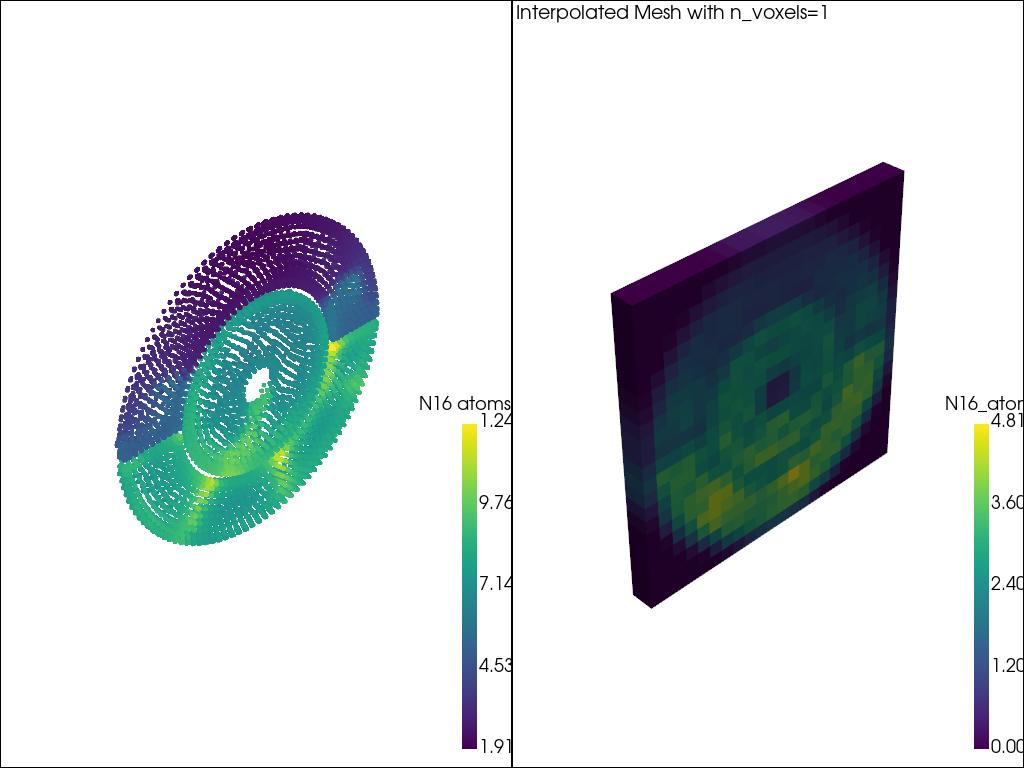

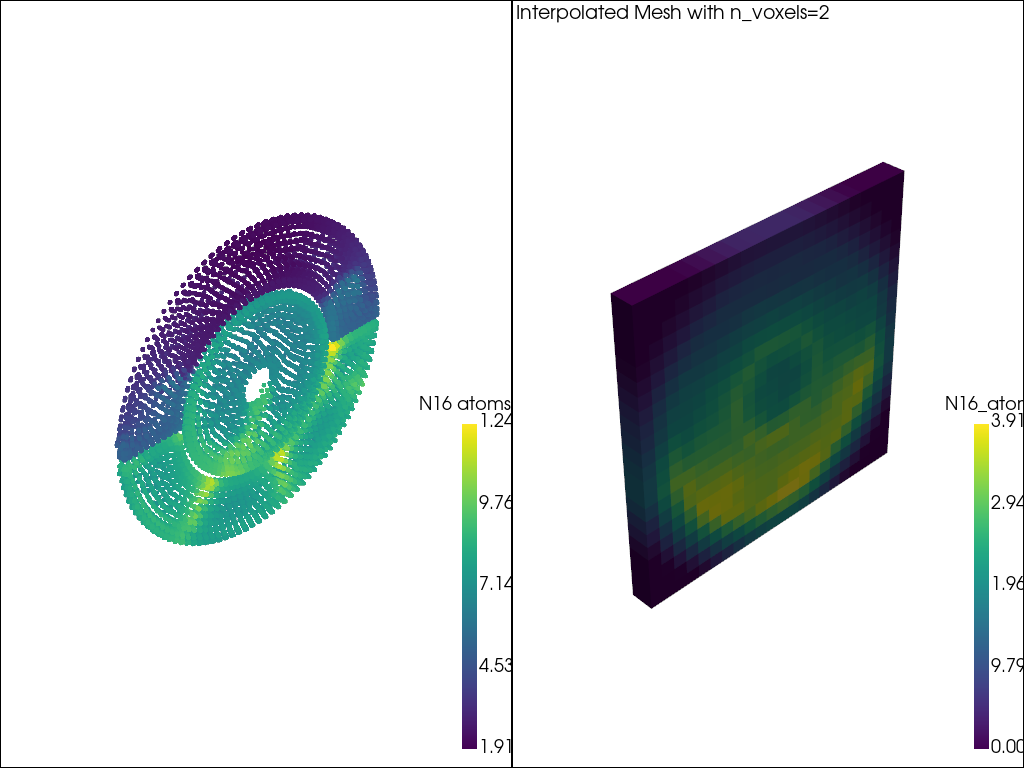

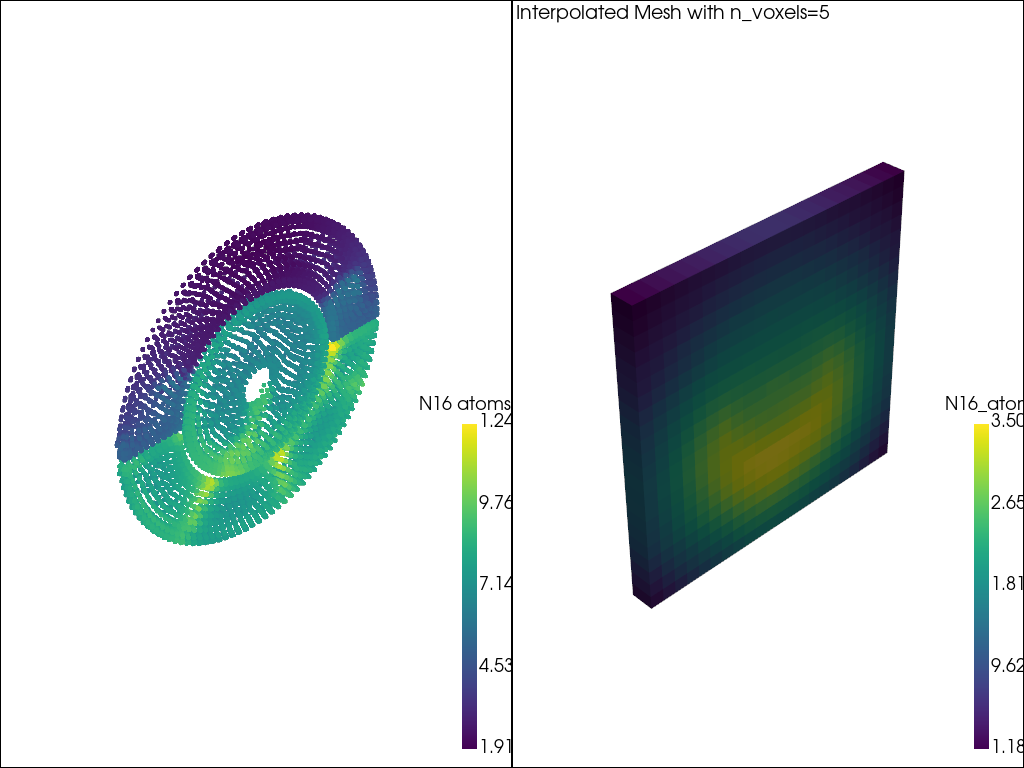

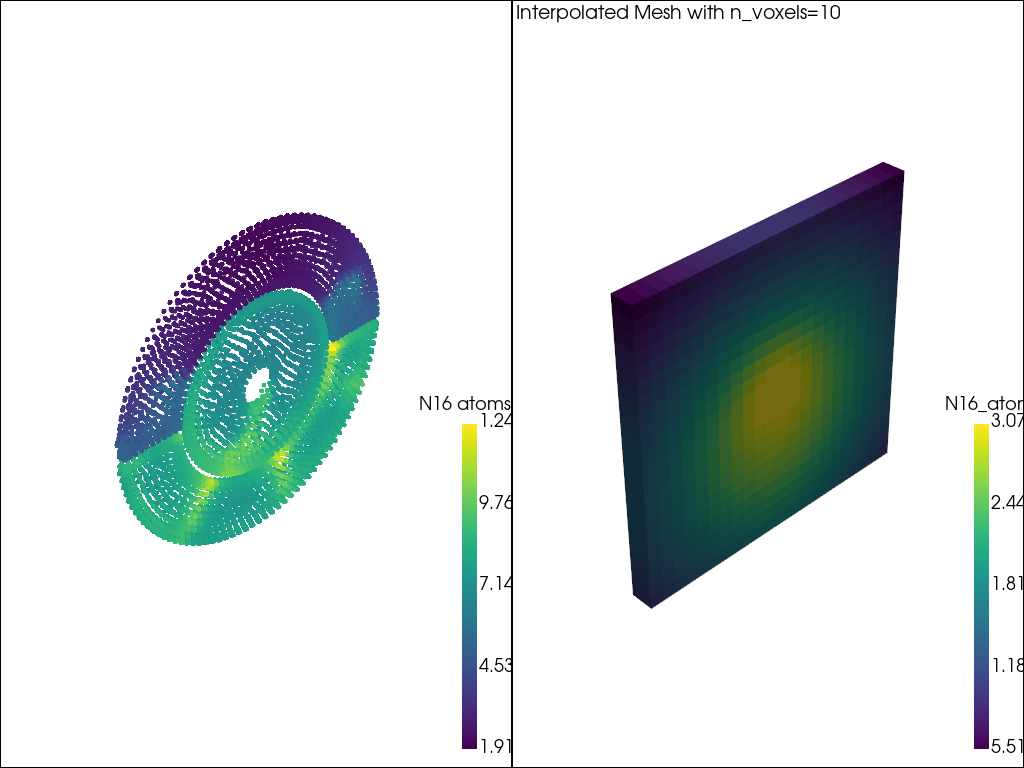

In [7]:
import pandas as pd
import pyvista as pv
from f4enix.output.cdgs import CDGS, SphereKernel, MeshByAverageDistance

source_activity = pd.read_csv('activity_example1.csv')
source_activity.columns = source_activity.columns.str.strip()  # Strip whitespace from column names
cloudpoint = pv.PolyData(source_activity[['x', 'y', 'z']].values)
cloudpoint['N16 atoms/m3'] = source_activity['n16'].values




for n_voxel in [1, 2, 5, 10]:
    cdgs = CDGS.from_cloud_point(
        'activity_example1.csv',
        {"N16": "n16"},
        interpolation_kernel=SphereKernel(n_voxels=n_voxel),
        mesh_definition=MeshByAverageDistance(factor=10),
        col_names={"x": "x", "y": "y", "z": "z", "vol": "cell-volume"}
        )

    interpolated_mesh = cdgs.mesh

    # plotting
    plotter = pv.Plotter(shape=(1, 2))

    plotter.subplot(0, 0)
    plotter.add_mesh(
        cloudpoint,
        scalars='N16 atoms/m3',
        scalar_bar_args={"vertical": True},
    )


    plotter.subplot(0, 1)
    plotter.add_mesh(
        cdgs.mesh,
        scalars='N16_atoms',
        scalar_bar_args={"vertical": True},
    )
    plotter.add_text(f"Interpolated Mesh with n_voxels={n_voxel}", font_size=12)

    plotter.show(jupyter_backend="static")


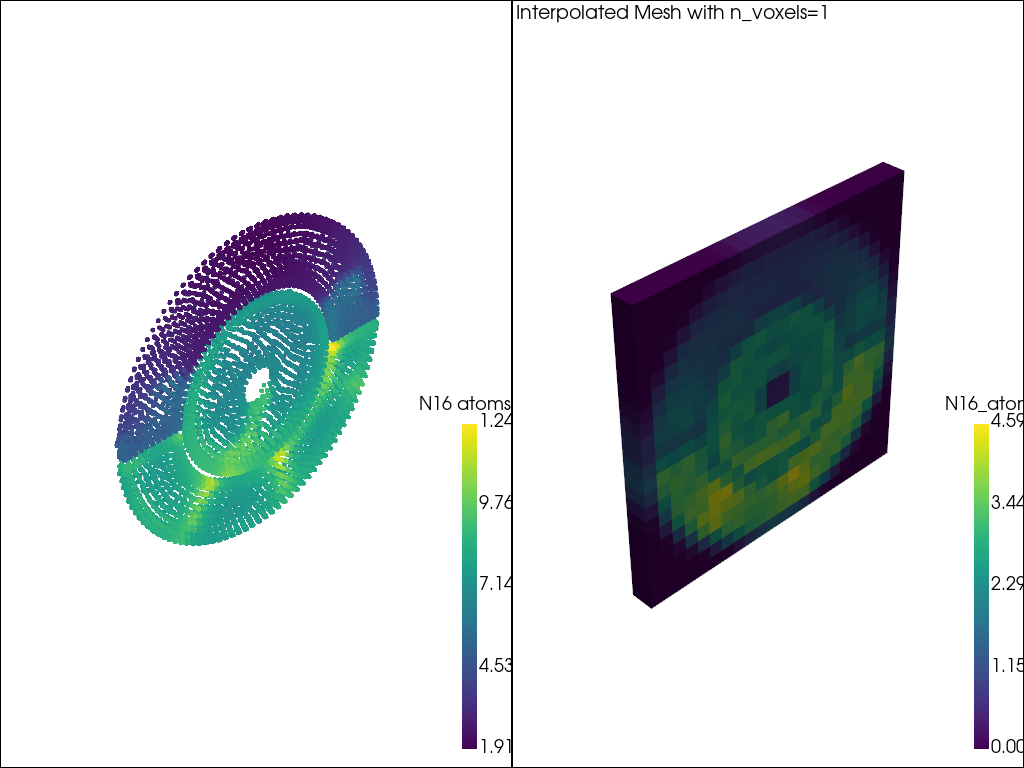

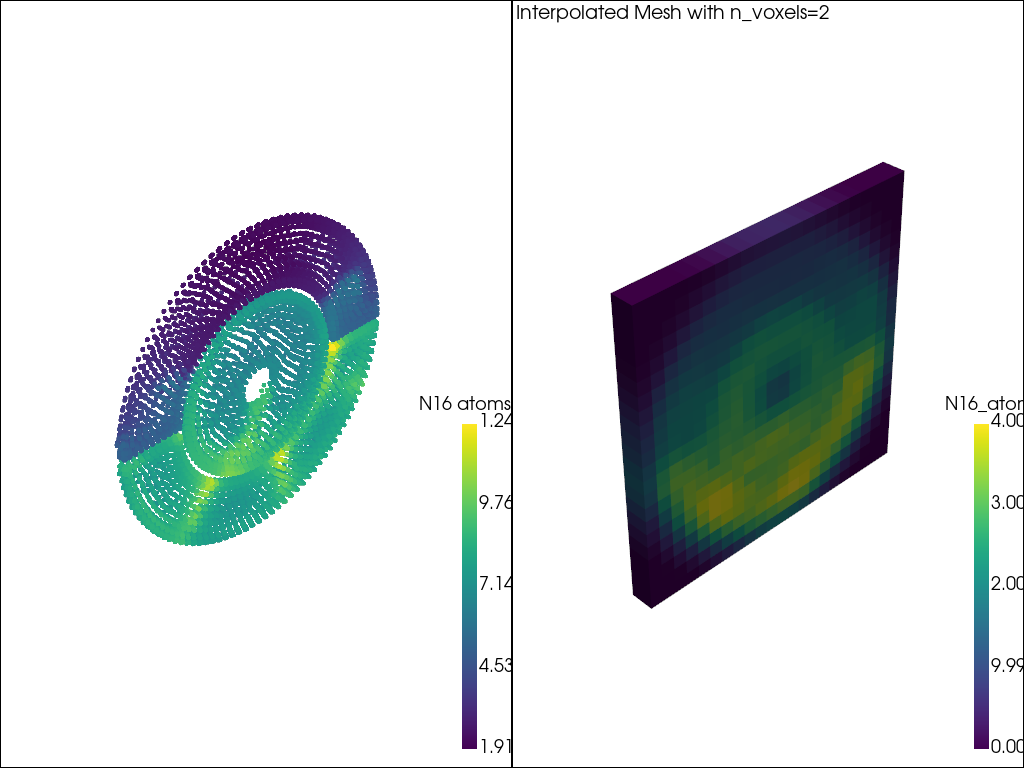

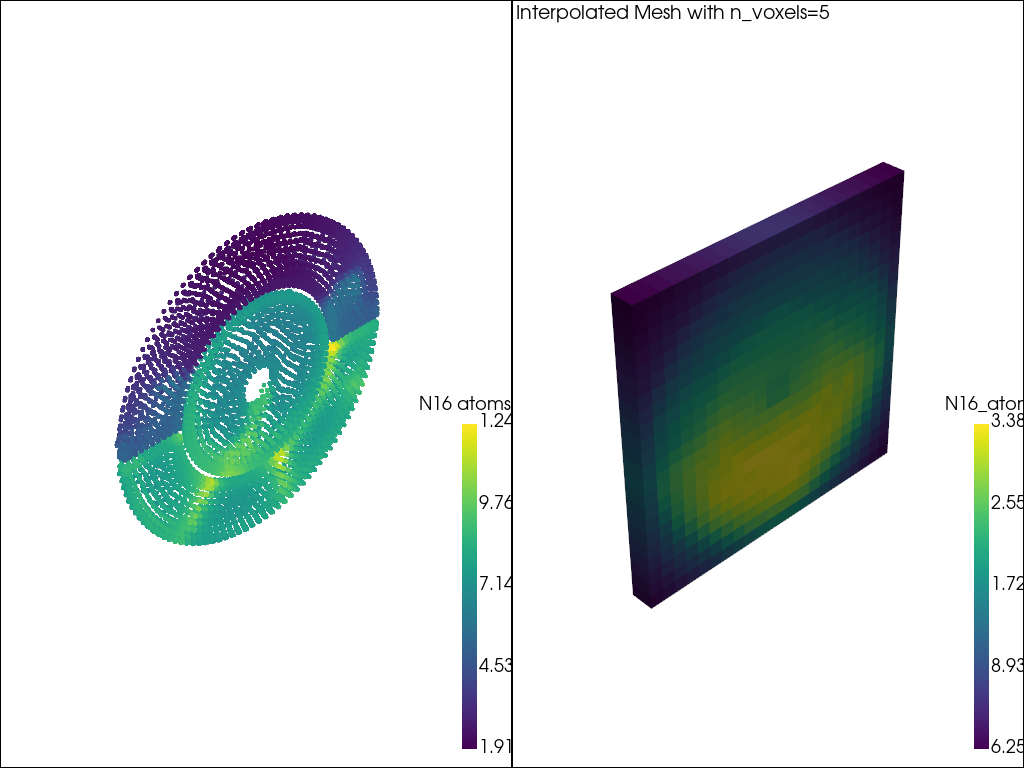

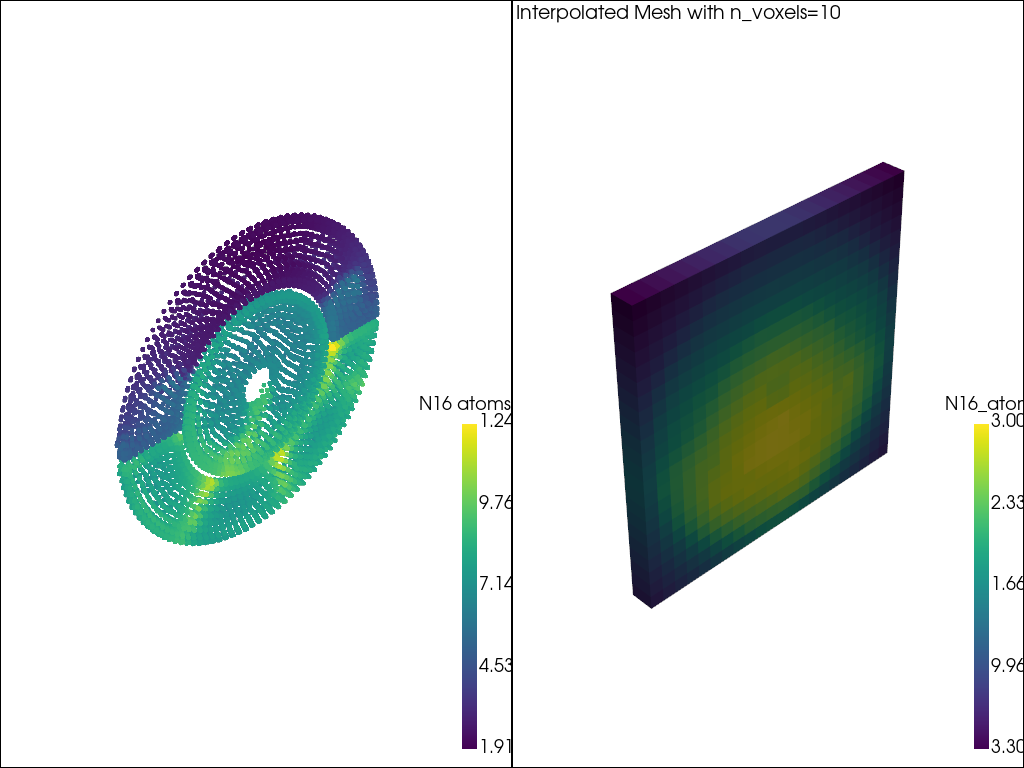

In [8]:
from f4enix.output.cdgs import CDGS, DistanceKernel

for n_voxel in [1, 2, 5, 10]:
    cdgs = CDGS.from_cloud_point(
        'activity_example1.csv',
        {"N16": "n16"},
        interpolation_kernel=DistanceKernel(n_voxels=n_voxel),
        mesh_definition=MeshByAverageDistance(factor=10),
        col_names={"x": "x", "y": "y", "z": "z", "vol": "cell-volume"}
        )

    interpolated_mesh = cdgs.mesh

    # plotting
    plotter = pv.Plotter(shape=(1, 2))

    plotter.subplot(0, 0)
    plotter.add_mesh(
        cloudpoint,
        scalars='N16 atoms/m3',
        scalar_bar_args={"vertical": True},
    )


    plotter.subplot(0, 1)
    plotter.add_mesh(
        cdgs.mesh,
        scalars='N16_atoms',
        scalar_bar_args={"vertical": True},
    )
    plotter.add_text(f"Interpolated Mesh with n_voxels={n_voxel}", font_size=12)

    plotter.show(jupyter_backend="static")


In [ ]:
sizes = original_um.compute_cell_sizes()

In [ ]:
sizes['Volume']

pyvista_ndarray([ 0.00647932,  0.01150175, -0.02659399, -0.00682155,
                  0.01116521,  0.00434963, -0.02203588, -0.01998227,
                  0.00521094,  0.00066384, -0.00660754, -0.00553925,
                 -0.00109276,  0.00062672,  0.00199875, -0.00673197,
                 -0.00557487,  0.00426564,  0.03244634,  0.02240261,
                 -0.01161346,  0.00157148,  0.0003049 ,  0.00092305,
                  0.00818507, -0.00528525,  0.02928998,  0.0062231 ,
                 -0.03545857, -0.00846946,  0.0197051 , -0.00804099,
                  0.01149098, -0.01082596, -0.01837991,  0.00742746,
                 -0.00537574,  0.01503009, -0.01287519,  0.00329671,
                  0.00130528,  0.01420579, -0.00657221, -0.00022629,
                 -0.00401403,  0.0062574 ,  0.01203994,  0.01799013,
                 -0.00658505, -0.00188814, -0.00287342,  0.0066716 ,
                 -0.00405002, -0.00367726,  0.01039079,  0.02573402,
                  0.03743201,  0.0

In [ ]:
import actigamma as ag

db = ag.Decay2012Database()

# get halflife of Co60
print(db.gethalflife("Co60"))

# get gamma lines of Co60
print(db.getenergies("Co60", spectype="gamma"))

166337000.0
[ 347140.  826100. 1173230. 1332490. 2158570. 2505690.]


In [ ]:
inv = ag.UnstablesInventory(data=[
    (db.getzai("Co60"), ag.activity_from_atoms(db, "Co60", 2.36853908671135e+22)),
    (db.getzai("Pu238"), ag.activity_from_atoms(db, "Pu238", 15970864933847.367)),
    (db.getzai("U235"), ag.activity_from_atoms(db, "U235", 1.730297451446211e+25))
])

In [ ]:
for zai, activity in inv:
    name = db.getname(zai)
    print(f"{name}: {activity:.3e} Bq")
    energies = db.getenergies(name, spectype='gamma')
    intensities = db.getintensities(name, spectype='gamma')*activity
    print(f"Gamma lines for {name}:")
    for energy, intensity in zip(energies, intensities):
        print(f"  Energy: {energy:.2f} keV, Intensity: {intensity:.3e} Bq")

Co60: 9.870e+13 Bq
Gamma lines for Co60:
  Energy: 347140.00 keV, Intensity: 7.402e+09 Bq
  Energy: 826100.00 keV, Intensity: 7.501e+09 Bq
  Energy: 1173230.00 keV, Intensity: 9.855e+13 Bq
  Energy: 1332490.00 keV, Intensity: 9.868e+13 Bq
  Energy: 2158570.00 keV, Intensity: 1.184e+09 Bq
  Energy: 2505690.00 keV, Intensity: 1.974e+06 Bq
Pu238: 4.000e+03 Bq
Gamma lines for Pu238:
  Energy: 34300.00 keV, Intensity: 2.440e-09 Bq
  Energy: 43498.00 keV, Intensity: 1.580e+00 Bq
  Energy: 62800.00 keV, Intensity: 9.600e-07 Bq
  Energy: 99853.00 keV, Intensity: 2.940e-01 Bq
  Energy: 140500.00 keV, Intensity: 2.680e-07 Bq
  Energy: 152720.00 keV, Intensity: 3.748e-02 Bq
  Energy: 174600.00 keV, Intensity: 2.080e-07 Bq
  Energy: 192800.00 keV, Intensity: 6.400e-08 Bq
  Energy: 200980.00 keV, Intensity: 1.632e-04 Bq
  Energy: 203200.00 keV, Intensity: 3.480e-07 Bq
  Energy: 234600.00 keV, Intensity: 4.800e-08 Bq
  Energy: 236400.00 keV, Intensity: 1.280e-06 Bq
  Energy: 258200.00 keV, Intensity

In [ ]:
volume.array_names

NameError: name 'volume' is not defined